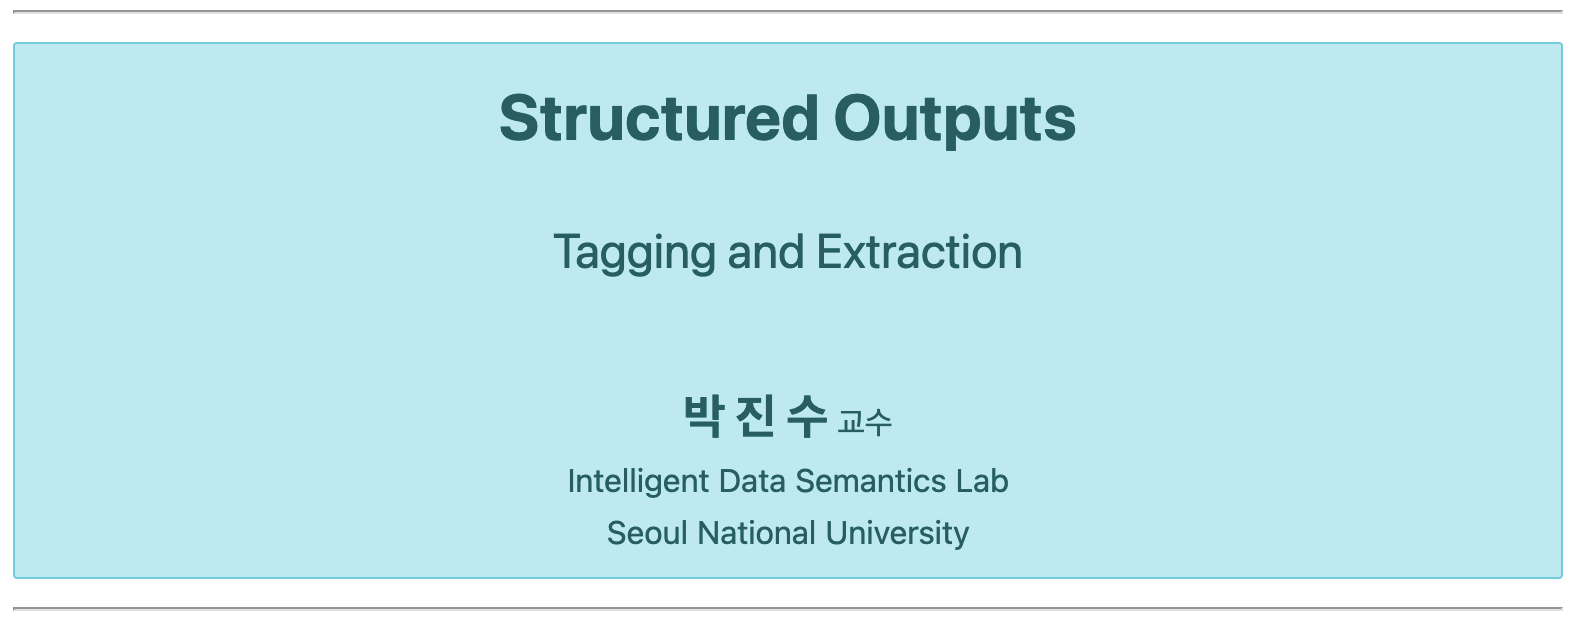

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain과 DeepLearning.AI가 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#Structured-Outputs" data-toc-modified-id="Structured-Outputs-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Structured Outputs</a></span></li><li><span><a href="#Tagging-with-Structured-Outputs" data-toc-modified-id="Tagging-with-Structured-Outputs-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Tagging with Structured Outputs</a></span></li><li><span><a href="#Extraction-with-Structured-Outputs" data-toc-modified-id="Extraction-with-Structured-Outputs-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Extraction with Structured Outputs</a></span></li><li><span><a href="#문서-요약-및-키워드-추출" data-toc-modified-id="문서-요약-및-키워드-추출-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>문서 요약 및 키워드 추출</a></span></li><li><span><a href="#Lab:-문서에서-인용한-논문-및-저자-추출" data-toc-modified-id="Lab:-문서에서-인용한-논문-및-저자-추출-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Lab: 문서에서 인용한 논문 및 저자 추출</a></span></li></ul></div>

# 패키지 설치 및 API 설정 

In [ ]:
!python -m pip install -qU python-dotenv pydantic langchain # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


# Structured Outputs

In [2]:
# --- 에이전트 구성
from langchain.messages import HumanMessage
from langchain.agents import create_agent
from pydantic import BaseModel


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

class ContactInfo(BaseModel):
        
agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

recorded_conversation = '''우리는 홍길동과 이야기했습니다. 
그는 A2I 아카데이에서 일하고 있습니다. 그의 번호는, 음, 공, 일, 공, 
일 이 삼, 사 오 육 칠 팔_이라고 했습니다. 잘 들으셨나요?
그리고 그의 이메일은 hong at a2i.com 이라고 했습니다. 
그는 비타민 50박스를 주문하고 싶어 했습니다.
'''
result = agent.invoke(
    {'messages': [HumanMessage(recorded_conversation)]}
)

result['structured_response']

ContactInfo(name='홍길동', email='hong@a2i.com', phone='010-1234-5678')

# Tagging with Structured Outputs

In [5]:
from pydantic import BaseModel, Field
from typing import Literal

class Tagging(BaseModel):
    """특정 정보가 포함된 텍스트에 태그를 지정합니다."""
    sentiment: Literal['긍정', '부정', '중립'] = Field(
        ...,  
        description='텍스트의 감성은 `긍정`, `부정` 또는 `중립` 중 하나여야 한다.'
    )
    score: int = Field(
        ...,
        description='텍스트의 감성을 1부터 10까지의 점수로 나타낸다. 10은 가장 긍정적인 감성, '
                    '1은 가장 부정적인 감성을 의미하며, 5~6은 중립적인 감성을 나타낸다.'
    )
    language: str = Field(
        ...,
        description='텍스트 언어',
    )
    language_code: str = Field(
        ...,
        description='텍스트 언어(ISO 639-1 코드여야 한다)'
    )
    korean: str | None = Field(
        None,
        description='텍스트가 한국어가 아니면 한국어로 번역한 텍스트(직역 보다는 의미 전달 중심)'
    )    

In [22]:
# --- 모델 초기화
from langchain.agents import create_agent

INSTRUCTION = '''신중하게 생각한 후 지시에 따라 텍스트에 
태그를 지정하세요. 한국어로 번역할 때는 존칭어를 사용합니다.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

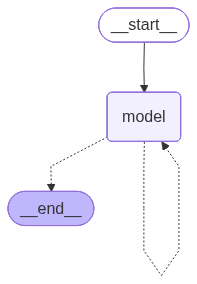

In [7]:
agent

In [23]:
# --- (방법 1) better -----------------------------------------------------------
from langchain.messages import HumanMessage

review = '새로 개봉한 영화 너무 좋았어요!'  
result = agent.invoke({'messages': [HumanMessage(review)]})
result['structured_response']

Tagging(sentiment='긍정', score=9, language='Korean', language_code='ko', korean=None)

In [24]:
result['structured_response'].model_dump()

{'sentiment': '긍정',
 'score': 9,
 'language': 'Korean',
 'language_code': 'ko',
 'korean': None}

In [26]:
# --- (방법 2) -----------------------------------------------------------
from langchain.chat_models import init_chat_model

review = '새로 개봉한 영화 너무 좋았어요!'  

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model  = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

result = model.invoke([HumanMessage(review)])
result

Tagging(sentiment='긍정', score=9, language='한국어', language_code='ko', korean='새로 개봉한 영화 너무 좋았어요!')

In [27]:
result.model_dump()

{'sentiment': '긍정',
 'score': 9,
 'language': '한국어',
 'language_code': 'ko',
 'korean': '새로 개봉한 영화 너무 좋았어요!'}

In [28]:
review = '''The movie offers a well-balanced 
mix of storytelling and visuals, but 
it may not appeal to everyone due to its slow pacing.
'''

result = agent.invoke({'messages': [HumanMessage(review)]})
result['structured_response']

Tagging(sentiment='중립', score=6, language='English', language_code='en', korean='이 영화는 스토리텔링과 비주얼이 조화롭게 어우러져 있지만, 전개가 느려서 모든 분께 매력적으로 느껴지지는 않을 수도 있습니다.')

In [29]:
reviews = [
    'La batterie de mon téléphone est trop courte et dure à peine une journée.', 
    ('La calidad de la cámara de mi teléfono es aceptable y funciona bien en la '
     'mayoría de las condiciones, aunque podría mejorar en situaciones de poca luz.'),  
    ('La qualità del segnale del mio telefono è generalmente buona, '
     'anche se a volte potrebbe essere migliorata in alcune aree.'),  
    'Сенсорный экран моего телефона не реагирует и иногда не регистрирует касания.',  
    ('Bản cập nhật phần mềm mới nhất đã cải thiện hiệu suất của điện thoại '
     'và giúp hệ thống hoạt động mượt mà hơn.'),
    'The phone is reliable and easy to use, but the battery life could be better.',
    ('내가 사용하고 있는 휴대폰은 터치 반응이 둔해서 화면을 여러 번 눌러야 하는 경우가 많고, 때때로 입력이 '
     '제대로 되지 않아 불편하다. 또한, 기기가 과열되는 문제가 심각한데, 특히 게임이나 동영상을 볼 때 뒷면이 '
     '너무 뜨거워져 장시간 사용하기 어렵다. 저장 공간도 부족해서 몇 개의 앱과 사진만 저장해도 금방 용량이 꽉 '
     '차버린다. 게다가, 운영 체제 업데이트도 자주 지원되지 않아 최신 기능을 사용할 수 없는 경우가 많다.')
]

for review in reviews:
    result = agent.invoke({'messages': [HumanMessage(review)]})
    print(f'\n{repr(result['structured_response'])}\n\n{'-' * 55}')
else:
    print('\n--- 작업을 종료했습니다.', '-' * 55)


Tagging(sentiment='부정', score=3, language='French', language_code='fr', korean='제 휴대폰 배터리 수명이 너무 짧아서 하루도 간신히 버팁니다.')

-------------------------------------------------------

Tagging(sentiment='중립', score=6, language='Spanish', language_code='es', korean='제 휴대폰 카메라 화질은 무난하고 대부분의 상황에서 잘 작동하지만, 다소 어두운 환경에서는 개선될 여지가 있습니다.')

-------------------------------------------------------

Tagging(sentiment='긍정', score=7, language='Italian', language_code='it', korean='제 휴대폰의 신호 품질은 전반적으로 좋은 편이지만, 일부 지역에서는 가끔 더 개선될 수 있을 것 같습니다.')

-------------------------------------------------------

Tagging(sentiment='부정', score=3, language='Russian', language_code='ru', korean='휴대폰 터치스크린이 반응하지 않고, 가끔 터치를 인식하지 못합니다.')

-------------------------------------------------------

Tagging(sentiment='긍정', score=9, language='Vietnamese', language_code='vi', korean='최신 소프트웨어 업데이트로 휴대전화 성능이 개선되었고, 시스템이 더 부드럽게 작동하게 되었습니다.')

-------------------------------------------------------

Tagging(sentiment='중립', score=6, langua

# Extraction with Structured Outputs

In [30]:
from pydantic import BaseModel, Field


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

class Person(BaseModel):
    """사람에 대한 정보"""

class Information(BaseModel):
    """추출할 정보"""

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [31]:
# --- 모델 초기화
from langchain.agents import create_agent

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [32]:
user_message = '라이언은 21살입니다.'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
result['structured_response']

Information(people=[Person(name='라이언', age=21)])

In [34]:
# --- model_dump -> 딕셔너리 형식으로 변환해서 출력 
user_message = '라이언은 21살이고 그의 엄마는 네오입니다.'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
result['structured_response'].model_dump()

{'people': [{'name': '라이언', 'age': 21}, {'name': '네오', 'age': None}]}

In [36]:
user_message = '새로 개봉한 영화 너무 좋았어요!'  
result = agent.invoke({'messages': [HumanMessage(user_message)]})
result['structured_response']

Information(people=[])

# 문서 요약 및 키워드 추출

In [3]:
from langchain_community.document_loaders import WebBaseLoader

URL = 'https://www.freecodecamp.org/news/the-agentic-ai-handbook/'
loader = WebBaseLoader(URL)
documents = loader.load()
len(documents)  

1

In [4]:
doc = documents[0]

In [5]:
print(doc.metadata)

{'source': 'https://www.freecodecamp.org/news/the-agentic-ai-handbook/', 'title': "The Agentic AI Handbook: A Beginner's Guide to Autonomous Intelligent Agents", 'description': 'You may have heard about “Agentic AI” systems and wondered what they’re all about. Well, in basic terms, the idea behind Agentic AI is that it can see its surroundings, set and pursue goals, plan and reason through many processes, and learn from expe...', 'language': 'en'}


In [6]:
len(doc.page_content)

38183

In [7]:
# 정규 표현식을 사용하여 줄바꿈(\n)과 탭(\t) 중 하나 이상의 연속된 패턴을 빈칸 하나로 대체하여 출력한다.
import re
print(re.sub(r'[\n\t]+', ' ', doc.page_content[:3000]))  

 The Agentic AI Handbook: A Beginner's Guide to Autonomous Intelligent Agents Menu Menu Forum Curriculum Donate                             May 28, 2025                          /                                 #AI                              The Agentic AI Handbook: A Beginner's Guide to Autonomous Intelligent Agents                                              Balajee Asish Brahmandam                                       You may have heard about “Agentic AI” systems and wondered what they’re all about. Well, in basic terms, the idea behind Agentic AI is that it can see its surroundings, set and pursue goals, plan and reason through many processes, and learn from experience. Unlike chatbots or rule-based software, agentic AI actively responds to user requests. It may break activities into smaller tasks, make decisions based on a high-level goal, and change its behavior over time using tools or other specialized AI components. To summarize, agentic AI systems "solve complex, multi-s

In [8]:
from pydantic import BaseModel, Field

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

class Overview(BaseModel):
    """문서의 개요"""

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [10]:
# --- 모델 초기화
from langchain.agents import create_agent

INSTRUCTION = '''명시적으로 제공받지 않은 내용은 
추측하지 말고 주어진 내용만을 기반으로 관련 정보를 추출하세요. 
한국어로 대답하세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [12]:
result = agent.invoke({'messages': [HumanMessage(doc.page_content)]})
result['structured_response']

Overview(summary='이 문서는 ‘에이전틱 AI(Agentic AI)’를 초보자 관점에서 설명합니다. 에이전틱 AI는 주변/상황을 인지하고 목표를 설정·추구하며, 계획(Planning)과 추론(Reasoning), 도구 사용(Tools), 메모리(Memory)를 결합해 복잡한 다단계 문제를 비교적 자율적으로 해결하는 시스템으로 정의됩니다. 반대로 반응형(비에이전틱) AI는 입력에 대해 사전 정의된 방식으로 즉시 응답하는 데 초점이 있습니다.\n\n문서는 에이전틱 AI의 핵심 구성요소(자율성, 목표지향 행동, 계획, 추론, 메모리)를 설명하고, 에이전틱 AI가 ‘무엇을 해야 하는지’는 주로 (1) 사전학습된 LLM, (2) 프롬프트로 부여된 구조, (3) 개발자가 연결해준 도구, (4) 제한적 메모리로부터 나온다고 정리합니다. 또한 현재 수준은 제한된 환경의 ‘부분적 에이전트 기능’이 상용/적용되고 있으나, 범용적이고 장기계획·지속학습이 가능한 완전 자율 에이전트는 아직 실험/프로토타입 단계라고 설명합니다.\n\n구현 관점에서는 RL 에이전트, LLM 기반 에이전트(ReAct, plan-and-execute), 멀티에이전트 오케스트레이션(AutoGen, ChatDev, MetaGPT 등), 고전적 계획/기호 AI, 도구-증강 추론(RAG 포함) 같은 접근을 소개합니다. 동시에 정렬(alignment)·가치 명세, 의도치 않은 결과(루프홀/보상 해킹 유사), 안전·보안(민감 데이터/도구 접근, 환각의 위험 증폭), 멀티에이전트 조정·확장, 윤리·법적 책임/투명성/편향 등의 과제를 강조합니다.\n\n마지막으로 Python과 LangChain을 이용해 Wikipedia 도구를 붙인 간단한 에이전트를 만드는 튜토리얼(환경 설정, Wikipedia Tool 등록, ChatOpenAI 기반 에이전트 초기화, 목표 질의 실행, ConversationBufferMemory로 대화 메모리 추가)을 단계별 코드로 제공합니다.', language='영어', keyword

In [13]:
print(result['structured_response'].language)
print('-' * 11)
print(result['structured_response'].keywords)
print('-' * 11)
print(result['structured_response'].summary)

영어
-----------
Agentic AI, Reactive AI, 자율성(Autonomy), 목표지향(Goal-Directed Behavior), 계획(Planning), 추론(Reasoning), 메모리(Memory), LLM 에이전트, ReAct, Plan-and-Execute, 도구 사용(Tool use), RAG, LangChain, 멀티에이전트, AutoGPT, BabyAGI, OpenDevin, 안전·정렬(Alignment), 보안·윤리
-----------
이 문서는 ‘에이전틱 AI(Agentic AI)’를 초보자 관점에서 설명합니다. 에이전틱 AI는 주변/상황을 인지하고 목표를 설정·추구하며, 계획(Planning)과 추론(Reasoning), 도구 사용(Tools), 메모리(Memory)를 결합해 복잡한 다단계 문제를 비교적 자율적으로 해결하는 시스템으로 정의됩니다. 반대로 반응형(비에이전틱) AI는 입력에 대해 사전 정의된 방식으로 즉시 응답하는 데 초점이 있습니다.

문서는 에이전틱 AI의 핵심 구성요소(자율성, 목표지향 행동, 계획, 추론, 메모리)를 설명하고, 에이전틱 AI가 ‘무엇을 해야 하는지’는 주로 (1) 사전학습된 LLM, (2) 프롬프트로 부여된 구조, (3) 개발자가 연결해준 도구, (4) 제한적 메모리로부터 나온다고 정리합니다. 또한 현재 수준은 제한된 환경의 ‘부분적 에이전트 기능’이 상용/적용되고 있으나, 범용적이고 장기계획·지속학습이 가능한 완전 자율 에이전트는 아직 실험/프로토타입 단계라고 설명합니다.

구현 관점에서는 RL 에이전트, LLM 기반 에이전트(ReAct, plan-and-execute), 멀티에이전트 오케스트레이션(AutoGen, ChatDev, MetaGPT 등), 고전적 계획/기호 AI, 도구-증강 추론(RAG 포함) 같은 접근을 소개합니다. 동시에 정렬(alignment)·가치 명세, 의도치 않은 결과(루프홀/보상 해킹 유사), 안전·보안(민감 데이터/도구 접근, 환각의 위험 증폭), 멀티에

# Lab: 문서에서 인용한 논문 및 저자 추출

- - -
**목표**
- 다음 URL의 **arXiv HTML** 아티클을 사용한다.
    + URL: https://arxiv.org/html/2508.11957v1
- 로드한 아티클이 **언급하는 다른 논문들**의 정보를 추출한다.

**요구사항**
1. **URL 기반 문서 로드**: 주어진 URL의 웹 아티클을 로드한다.
2. **언급 논문 추출**: 아티클 본문에서 다른 논문을 언급한 부분을 찾아, 해당 논문들의 정보를 추출한다.
3. **구조화 출력**: 각 논문에 대해 다음 필드를 갖는 구조로 반환한다.
   - `paper_title` (논문 제목)
   - `authors` (저자들, 없으면 `None`)
   - `year` (게재 연도, 없으면 `None`)
4. **아티클 자체 제외**: 아티클 자신의 제목은 목록에서 제외한다.
5. **빈 목록 처리**: 아티클이 다른 논문을 전혀 언급하지 않으면, 빈 리스트(`[]`)를 반환한다.

**제출 안내**    
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- `WebBaseLoader`로 URL 문서를 로드할 수 있다.
- 구조화한 출력이 필요하면 `PydanticOutputParser` 또는 JSON/딕셔너리 파싱을 활용한다.

</details>

- - -

In [ ]:
# YOUR CODE HERE

In [23]:
result['structured_response'].model_dump()

{'papers': [{'paper_title': 'Multiagent systems: A survey from a machine learning perspective.',
   'authors': 'Peter Stone and Manuela Veloso.',
   'year': '2000'},
  {'paper_title': 'An image is worth 16x16 words: Transformers for image recognition at scale.',
   'authors': 'Alexey et al. Dosovitskiy.',
   'year': '2021'},
  {'paper_title': 'The Fifth Generation: Artificial Intelligence and Japan’s Computer Challenge to the World.',
   'authors': 'Edward A. Feigenbaum and Pamela McCorduck.',
   'year': '1983'},
  {'paper_title': 'Automated Planning: Theory and Practice.',
   'authors': 'Malik Ghallab, Dana Nau, and Paolo Traverso.',
   'year': '2004'},
  {'paper_title': 'Reinforcement learning: A survey.',
   'authors': 'Leslie Pack Kaelbling, Michael L Littman, and Andrew W Moore.',
   'year': '1996'},
  {'paper_title': 'Reinforcement Learning: An Introduction.',
   'authors': 'Richard S Sutton and Andrew G Barto.',
   'year': '2018'},
  {'paper_title': 'Mastering the game of go wit

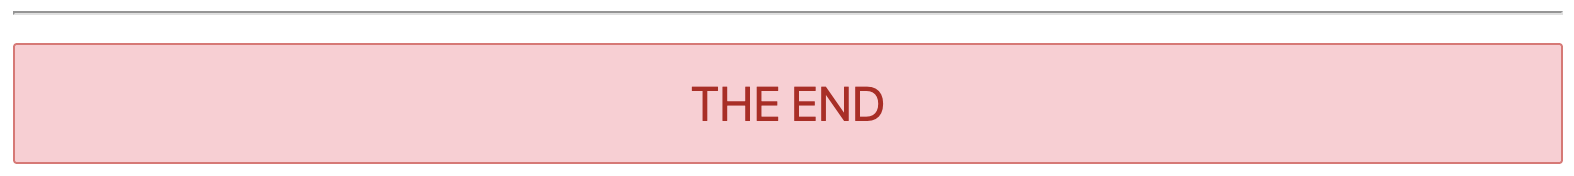